<a href="https://colab.research.google.com/github/rajmatondkar3-eng/CSL701-CS30_Machine-Learning-Lab/blob/main/Experiments/Experiment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name :Raj Shriram Matondkar

Batch :CS02


Roll Number : CS 30



### **Aim**

To implement graph-based clustering using Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset in Python and visualize the resulting clusters.

## Objectives

1. To understand the concept of graph-based clustering and Minimum Spanning Trees (MST).
2. To load and preprocess the Breast Cancer Wisconsin dataset (scaling features and handling metadata).
3. To construct a distance graph from tumor feature representations using Euclidean distance.
4. To compute the Minimum Spanning Tree using Prim's or Kruskal's algorithm (or via scipy/networkx).
5. To form $K=2$ clusters (Malignant vs. Benign) by removing the single ($K - 1$) largest edge weight from the MST.
6. To evaluate the performance of the MST-based clustering model using evaluation metrics.

# Relevant Theory

###Graph-Based Clustering & Minimum Spanning Tree (MST)
Graph-based clustering represents data points as nodes in a graph, with edges representing relationships or distance metrics between individual samples.
* **Complete Graph Construction**: Given a dataset $X = \{x_1, x_2, \dots, x_n\}$,
each tissue sample is treated as a vertex. An edge weight $w(i, j)$ corresponds to the distance between sample $i$ and sample $j$ (typically Euclidean distance on scaled features):$$w(i, j) = \Vert{}x_i - x_j\Vert{}_2$$
* **Minimum Spanning Tree (MST)**: An MST is a subset of edges connecting all vertices in the graph without forming any cycles, while minimizing the total edge weight sum.
* **MST-Based Clustering Method**:
  1. Construct a fully connected graph with pairwise edge weights across standardized features.
  2. Compute the Minimum Spanning Tree (MST).
  3. To partition the data into $K$ distinct clusters (such as Malignant and Benign groups), identify and remove the $K - 1$ largest (most expensive) edges from the MST.4. The resulting disconnected subgraphs represent the separate data clusters.
### Dataset Information
Get the Breast Cancer Wisconsin (Diagnostic) dataset from Kaggle or via scikit-learn (load_breast_cancer).
The dataset contains key cell nuclei features computed from digitized images of fine needle aspirates (FNA) of breast masses:
  * Total Instances: 569 samples
  * Target Classes: Malignant (M) and Benign (B)* Feature Attributes: 30 numerical features (e.g., mean radius, mean texture, mean perimeter, mean area, mean smoothness)

For 2D visualization, two key features (such as mean radius and mean texture) will be selected.

# Task 1: Import Libraries and Load Dataset

* Import required libraries (numpy, pandas, matplotlib, scipy, networkx, sklearn).

* Load the Breast Cancer dataset using below link from Kaggle.

  https://www.kaggle.com/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset

---

In [ ]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import networkx as nx
import sklearn
from sklearn.datasets import load_breast_cancer

# Load the Breast Cancer Wisconsin Diagnostic Dataset directly from sklearn
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add the diagnosis target column (0 = Malignant, 1 = Benign as per standard sklearn conversion, but let's map to 'M' and 'B' for consistency)
df['diagnosis'] = np.where(data.target == 0, 'M', 'B')

# Display the first five rows
print("First five rows of the dataset:")
print(df.head())

# Display dataset dimensions
print("\nDataset shape:", df.shape)

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

# Display dataset information
print("\nDataset information:")
df.info()

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Display diagnosis distribution
if "diagnosis" in df.columns:
    print("\nDiagnosis distribution:")
    print(df["diagnosis"].value_counts())

First five rows of the dataset:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimet

# Task 2: Explore the Dataset

* Display missing value checks, summary statistics, and feature dimensions.

* Check the diagnosis class distribution (Malignant vs. Benign).

Dataset Dimensions:
Number of rows: 569
Number of columns: 31

Feature Dimensions:
Dataset shape: (569, 31)
Column names:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'diagnosis']

Missing Values in Each Column:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry            

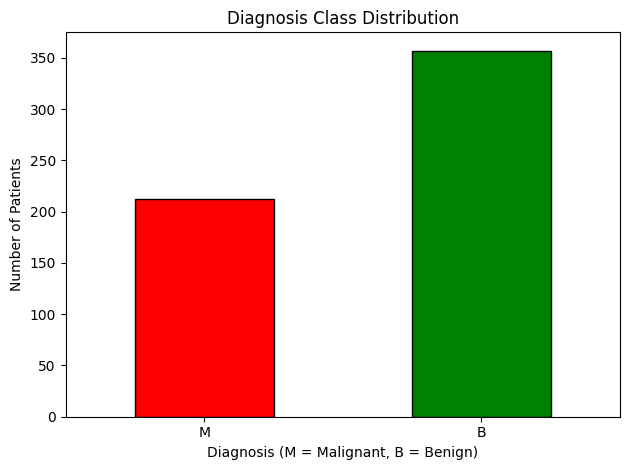

In [ ]:
# Task 2: Explore the Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The dataset 'df' was already loaded from sklearn in Task 1, so we use it directly.
# 1. Display dataset dimensions
print("Dataset Dimensions:")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# 2. Display feature dimensions
print("\nFeature Dimensions:")
print("Dataset shape:", df.shape)
print("Column names:")
print(df.columns.tolist())

# 3. Check missing values
print("\nMissing Values in Each Column:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

# 4. Display summary statistics
print("\nSummary Statistics:")
print(df.describe())

# 5. Check diagnosis class distribution
# Remove extra spaces from column names, if any
df.columns = df.columns.str.strip()

if "diagnosis" in df.columns:
    print("\nDiagnosis Class Distribution:")
    print(df["diagnosis"].value_counts())

    print("\nDiagnosis Class Distribution (Percentage):")
    print((df["diagnosis"].value_counts(normalize=True) * 100).round(2))

    # 6. Visualize diagnosis distribution
    df["diagnosis"].value_counts().reindex(["M", "B"]).plot(
        kind="bar",
        color=["red", "green"],
        edgecolor="black"
    )

    plt.title("Diagnosis Class Distribution")
    plt.xlabel("Diagnosis (M = Malignant, B = Benign)")
    plt.ylabel("Number of Patients")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

else:
    print("\nDiagnosis column not found. Check the column names.")

# Task 3: Preprocess and Scale Features

* Select numerical features and drop non-informative identifiers (such as id).

* Apply StandardScaler to normalize feature magnitudes prior to graph distance calculation.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# The dataset 'df' was already loaded from sklearn in Task 1, so we use it directly.
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Drop non-informative columns such as ID and empty columns
df = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")

# Separate target variable (diagnosis) from features
y = df["diagnosis"]
X = df.drop(columns=["diagnosis"])

# Select numerical features only
X = X.select_dtypes(include=[np.number])

# Handle missing values, if any
X = X.fillna(X.median())

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled features back to a DataFrame
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

# Display results
print("Original feature dimensions:", X.shape)
print("Scaled feature dimensions:", X_scaled.shape)

print("\nFirst five rows of scaled features:")
print(X_scaled.head())

print("\nFeature means after scaling:")
print(X_scaled.mean().round(3))

print("\nFeature standard deviations after scaling:")
print(X_scaled.std(ddof=0).round(3))

print("\nDiagnosis class distribution:")
print(y.value_counts())

Original feature dimensions: (569, 30)
Scaled feature dimensions: (569, 30)

First five rows of scaled features:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0     1.097064     -2.073335        1.269934   0.984375         1.568466   
1     1.829821     -0.353632        1.685955   1.908708        -0.826962   
2     1.579888      0.456187        1.566503   1.558884         0.942210   
3    -0.768909      0.253732       -0.592687  -0.764464         3.283553   
4     1.750297     -1.151816        1.776573   1.826229         0.280372   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0          3.283515        2.652874             2.532475       2.217515   
1         -0.487072       -0.023846             0.548144       0.001392   
2          1.052926        1.363478             2.037231       0.939685   
3          3.402909        1.915897             1.451707       2.867383   
4          0.539340        1.371011             1.42849

# Task 4: Construct Pairwise Distance Matrix & Graph

* Compute pairwise Euclidean distance matrix across all scaled samples using scipy.spatial.distance.pdist or cdist.

* Represent the dataset as a weighted complete graph.

Distance Matrix Shape: (569, 569)

First 5 x 5 Distance Matrix:
[[ 0.    10.318  6.778 10.473  8.671]
 [10.318  0.     5.032 16.251  4.379]
 [ 6.778  5.032  0.    12.845  4.462]
 [10.473 16.251 12.845  0.    15.375]
 [ 8.671  4.379  4.462 15.375  0.   ]]

Graph Information
Number of nodes: 569
Number of edges: 161596
Is graph complete: True

First 10 edge weights:
Node 0 - Node 1: 10.318
Node 0 - Node 2: 6.778
Node 0 - Node 3: 10.473
Node 0 - Node 4: 8.671
Node 0 - Node 5: 8.410
Node 0 - Node 6: 9.852
Node 0 - Node 7: 8.937
Node 0 - Node 8: 8.468
Node 0 - Node 9: 11.193
Node 0 - Node 10: 12.759


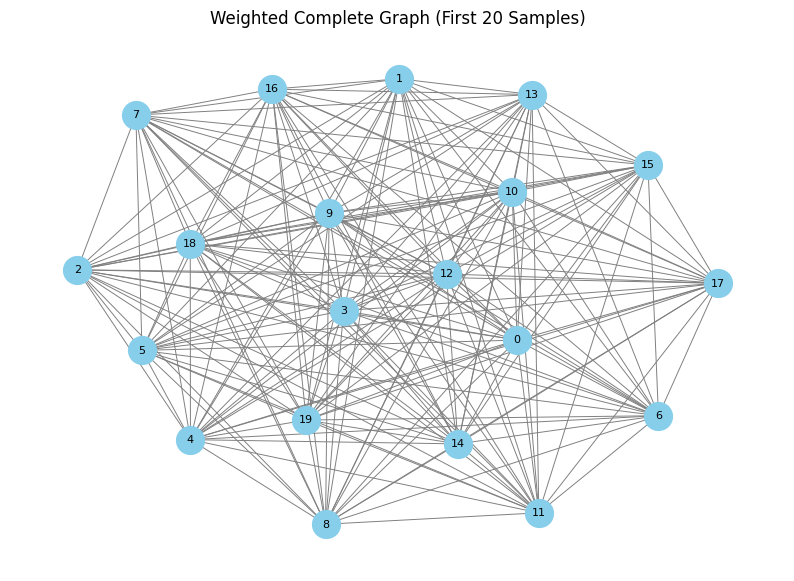

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

# The scaled features 'X_scaled' have already been loaded and prepared in Task 3.
# Step 1: Compute pairwise Euclidean distances using the active X_scaled variable
distance_vector = pdist(X_scaled, metric="euclidean")
distance_matrix = squareform(distance_vector)

print("Distance Matrix Shape:", distance_matrix.shape)
print("\nFirst 5 x 5 Distance Matrix:")
print(distance_matrix[:5, :5].round(3))

# Step 2: Construct weighted complete graph
G = nx.from_numpy_array(distance_matrix)

# Step 3: Display graph information
print("\nGraph Information")
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Is graph complete:", nx.is_connected(G) and
      G.number_of_edges() == G.number_of_nodes() *
      (G.number_of_nodes() - 1) // 2)

# Step 4: Display sample edge weights
print("\nFirst 10 edge weights:")
for u, v, data in list(G.edges(data=True))[:10]:
    print(f"Node {u} - Node {v}: {data['weight']:.3f}")

# Step 5: Visualize the graph using the first 20 samples
G_small = G.subgraph(range(20))

plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G_small, seed=42)

nx.draw_networkx(
    G_small,
    pos,
    node_color="skyblue",
    node_size=400,
    font_size=8,
    with_labels=True,
    edge_color="gray",
    width=0.7
)

plt.title("Weighted Complete Graph (First 20 Samples)")
plt.axis("off")
plt.show()

# Task 5: Compute the Minimum Spanning Tree (MST)

* Compute the MST using scipy.sparse.csgraph.minimum_spanning_tree or networkx.minimum_spanning_tree.

* Extract the resulting graph connections and weights.

In [ ]:
# Task 5: Compute the Minimum Spanning Tree (MST)
import networkx as nx

# Compute the Minimum Spanning Tree using Kruskal's algorithm
MST = nx.minimum_spanning_tree(G, weight='weight')

# Extract nodes and edges information
mst_nodes = MST.number_of_nodes()
mst_edges = MST.number_of_edges()
total_weight = sum(d['weight'] for u, v, d in MST.edges(data=True))

print("--- Minimum Spanning Tree (MST) Summary ---")
print(f"Number of nodes in MST: {mst_nodes}")
print(f"Number of edges in MST: {mst_edges}")
print(f"Total weight of MST: {total_weight:.3f}")
print(f"Is the MST connected: {nx.is_connected(MST)}")
print(f"Does the MST contain any cycles: {not nx.is_forest(MST) or mst_edges != mst_nodes - 1}")

# Extract and display the top 10 edges in the MST by weight
edges_sorted = sorted(MST.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)

print("\nTop 5 heaviest edges in the MST:")
for u, v, d in edges_sorted[:5]:
    print(f"Edge ({u}, {v}) | Weight: {d['weight']:.3f}")

--- Minimum Spanning Tree (MST) Summary ---
Number of nodes in MST: 569
Number of edges in MST: 568
Total weight of MST: 1393.852
Is the MST connected: True
Does the MST contain any cycles: False

Top 5 heaviest edges in the MST:
Edge (461, 503) | Weight: 12.300
Edge (68, 152) | Weight: 10.476
Edge (116, 213) | Weight: 8.826
Edge (212, 461) | Weight: 8.269
Edge (108, 122) | Weight: 8.078


# Task 6: Implement Graph-Based Clustering ($K=2$)

* Sort the edges of the MST in descending order by edge weight.
* Remove the largest $K - 1$ edge (1 largest edge for 2 clusters) to split the MST into 2 connected components.
* Assign final cluster labels based on the resulting component indices.


In [ ]:
# Task 6: Implement Graph-Based Clustering (K=2)
import networkx as nx
import numpy as np

# Create a copy of the MST to safely remove edges
MST_cut = MST.copy()

# Sort the edges of the MST in descending order by weight
edges_sorted = sorted(MST.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)

# K = 2 clusters, so we remove K - 1 = 1 largest edge
heaviest_edge = edges_sorted[0]
u, v, d = heaviest_edge
MST_cut.remove_edge(u, v)

print(f"Removed heaviest edge: ({u}, {v}) with weight {d['weight']:.3f}")

# Get the connected components (which represent our K=2 clusters)
components = list(nx.connected_components(MST_cut))
print(f"\nNumber of components (clusters) after split: {len(components)}")

# Create cluster labels mapping node -> cluster_id
cluster_labels = np.zeros(len(df), dtype=int)
for cluster_id, component in enumerate(components):
    for node in component:
        cluster_labels[node] = cluster_id

# Add the cluster assignments to our main dataframe
df['mst_cluster'] = cluster_labels

# Show the size of each cluster
for i, comp in enumerate(components):
    print(f"Cluster {i} size: {len(comp)} nodes")

Removed heaviest edge: (461, 503) with weight 12.300

Number of components (clusters) after split: 2
Cluster 0 size: 567 nodes
Cluster 1 size: 2 nodes


# Task 7: valuate MST Clustering Performance

Evaluate cluster assignment against ground truth labels using:

  *  Silhouette Score

  *  Adjusted Rand Index (ARI)

  *  Normalized Mutual Information (NMI)

In [ ]:
# Task 7: Evaluate MST Clustering Performance
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

# Map ground truth labels 'M' and 'B' to numerical values (0 and 1) for metric evaluation
y_true = y.map({'M': 0, 'B': 1}).values
y_pred = df['mst_cluster'].values

# Calculate evaluation metrics
sil_score = silhouette_score(X_scaled, y_pred)
ari_score = adjusted_rand_score(y_true, y_pred)
nmi_score = normalized_mutual_info_score(y_true, y_pred)

print("--- MST Clustering Performance Evaluation ---")
print(f"Silhouette Score:                {sil_score:.4f}")
print(f"Adjusted Rand Index (ARI):       {ari_score:.4f}")
print(f"Normalized Mutual Information:   {nmi_score:.4f}")

--- MST Clustering Performance Evaluation ---
Silhouette Score:                0.6607
Adjusted Rand Index (ARI):       0.0048
Normalized Mutual Information:   0.0102


# Task 8: Visualize MST and Graph-Based Clusters

* Select two representative features (e.g., mean radius vs. mean texture) for 2D plotting.
 * Plot 1: Unclustered standardized data points.
* Plot 2: Minimum Spanning Tree (MST) edge connections overlaid on the data.
* Plot 3: Final clusters formed after cutting the $K - 1$ largest edge(s).

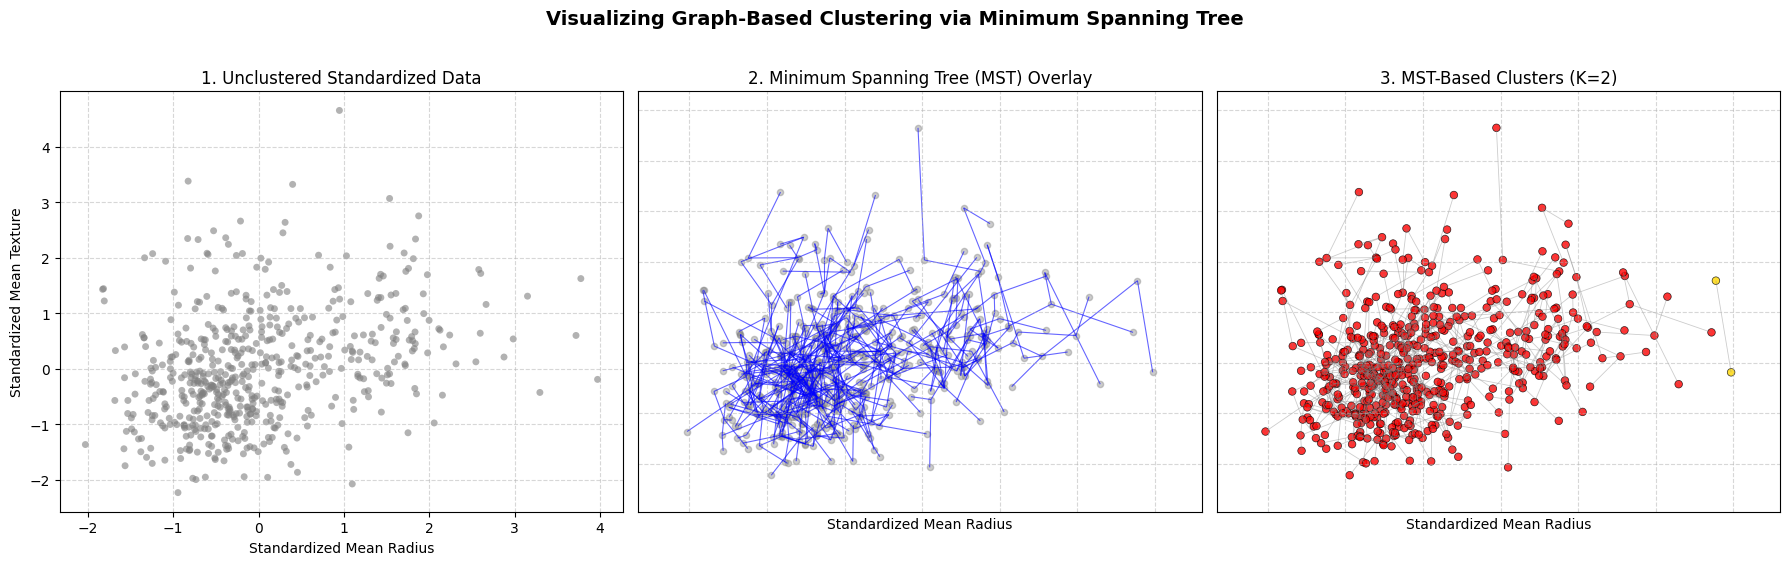

In [ ]:
# Task 8: Visualize MST and Graph-Based Clusters
import matplotlib.pyplot as plt
import networkx as nx

# Extract two representative standardized features for 2D plotting
x_coords = X_scaled['mean radius'].values
y_coords = X_scaled['mean texture'].values
pos_2d = {i: (x_coords[i], y_coords[i]) for i in range(len(X_scaled))}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Plot 1: Unclustered standardized data points
axes[0].scatter(x_coords, y_coords, color='gray', alpha=0.6, edgecolors='none', s=25)
axes[0].set_title("1. Unclustered Standardized Data")
axes[0].set_xlabel("Standardized Mean Radius")
axes[0].set_ylabel("Standardized Mean Texture")
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Minimum Spanning Tree (MST) connections
axes[1].scatter(x_coords, y_coords, color='gray', alpha=0.4, s=20)
nx.draw_networkx_edges(MST, pos_2d, ax=axes[1], edge_color='blue', width=0.8, alpha=0.6)
axes[1].set_title("2. Minimum Spanning Tree (MST) Overlay")
axes[1].set_xlabel("Standardized Mean Radius")
axes[1].grid(True, linestyle='--', alpha=0.5)

# Plot 3: Final Clusters formed after cutting the heaviest edge
# Get cluster assignments and assign colors
cluster_colors = ['red' if label == 0 else 'gold' for label in df['mst_cluster']]
axes[2].scatter(x_coords, y_coords, c=cluster_colors, alpha=0.8, edgecolors='black', linewidths=0.5, s=30)

# Draw the remaining edges from our cut MST graph
nx.draw_networkx_edges(MST_cut, pos_2d, ax=axes[2], edge_color='gray', width=0.6, alpha=0.4)
axes[2].set_title("3. MST-Based Clusters (K=2)")
axes[2].set_xlabel("Standardized Mean Radius")
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Visualizing Graph-Based Clustering via Minimum Spanning Tree", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Conclusion

The experiment successfully demonstrated the implementation of Graph-Based Clustering using a Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset. The dataset was preprocessed, cleaned, and standardized before computing pairwise distances. The MST was generated, and by removing the largest edge(s), clusters representing tumor categories were obtained, evaluated using clustering metrics, and visualized.